# Complete Speech DSP Analysis Pipeline

**Digital Signal Processing (DSP) Pipeline for Speech Analysis**

This notebook demonstrates a full **DSP pipeline** for speech signals: from loading a raw .wav file through filtering, time–frequency analysis, framing, windowing, and feature extraction. It is structured like an academic DSP assignment with clear sections, code, visualizations, and short explanations.

**Pipeline overview:** Load Audio → Raw Signal Analysis → FFT → Spectrogram (STFT) → Band-pass FIR Filter → FIR Filter Analysis → IIR Comparison → Before vs After Filtering → PSD → Wavelet Transform → Framing → Windowing → Spectral Leakage → Window Size → Feature Extraction → Feature Interpretation → Pipeline Summary

**Libraries:** `numpy`, `scipy`, `librosa`, `matplotlib`, `pywt`

In [2]:
# Imports and configuration
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy import signal
import pywt

# Use a speech .wav file (update path to your file; librosa can also load other formats)
AUDIO_PATH = "../data/voice2.m4a"  # or e.g. "path/to/your/speech.wav"
plt.rcParams["figure.figsize"] = (10, 4)

---
## 1. Load Audio

Load a speech signal using **librosa**. We load the audio file, print the sample rate and duration, and visualize the waveform.

/var/folders/rw/mrq8frv956d97wy41t6467mc0000gn/T/ipykernel_8642/3041418402.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(AUDIO_PATH, sr=None, mono=True)
/Users/quangle/Documents/projects/MSE_project/DSP/DSP501-Speaker-Identification-Project/venv/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Sample rate: 48000 Hz
Signal duration: 6.93 seconds
Number of samples: 332736


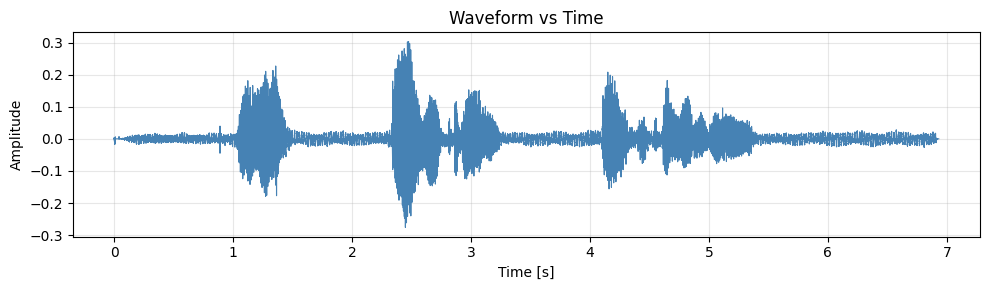

In [3]:
# Load audio file (sr=None preserves native sample rate)
y, sr = librosa.load(AUDIO_PATH, sr=None, mono=True)

# Print basic info
print(f"Sample rate: {sr} Hz")
print(f"Signal duration: {len(y) / sr:.2f} seconds")
print(f"Number of samples: {len(y)}")

# Waveform vs Time
t = np.arange(len(y)) / sr
plt.figure(figsize=(10, 3))
plt.plot(t, y, color="steelblue", linewidth=0.8)
plt.title("Waveform vs Time")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**What the waveform represents:** The waveform is the **time-domain** representation of the speech signal. The vertical axis (amplitude) corresponds to air pressure variation captured by the microphone; the horizontal axis is time. Voiced speech shows quasi-periodic oscillations (pitch), while unvoiced segments appear noisier. This view does not directly show frequency content—that requires frequency-domain analysis (FFT, spectrogram).

---
## 2. Raw Signal Analysis

Analyze the raw speech signal: inspect the waveform, compute amplitude statistics, and briefly discuss noise and variability typical of speech.

Amplitude statistics:
  Min:    -0.276154
  Max:    0.303040
  Mean:   -0.000009
  Std:    0.031101
  RMS:    0.031101


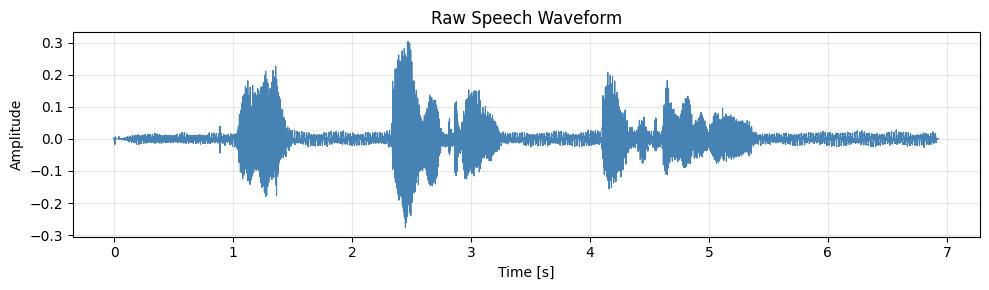

In [4]:
# Amplitude statistics
print("Amplitude statistics:")
print(f"  Min:    {np.min(y):.6f}")
print(f"  Max:    {np.max(y):.6f}")
print(f"  Mean:   {np.mean(y):.6f}")
print(f"  Std:    {np.std(y):.6f}")
print(f"  RMS:    {np.sqrt(np.mean(y**2)):.6f}")

# Waveform (same as above, for context in this section)
plt.figure(figsize=(10, 3))
plt.plot(t, y, color="steelblue", linewidth=0.8)
plt.title("Raw Speech Waveform")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Noise and variability in speech:** Speech signals are **non-stationary**: amplitude, spectral content, and periodicity change over time (e.g., vowels vs consonants, silence vs speech). Variability comes from different phonemes, speaking rate, and speaker identity. Background noise, room acoustics, and recording conditions add further variability. These properties motivate frame-based and time–frequency analysis rather than treating the whole signal as a single stationary process.

---
## 3. FFT (Frequency Analysis)

Compute the **Fast Fourier Transform** of the signal to obtain the frequency content. We use **numpy.fft** to compute the FFT, then the magnitude spectrum, and plot frequency vs magnitude.

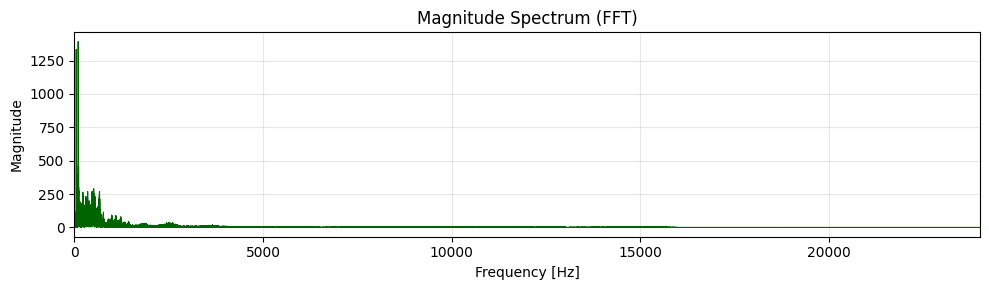

In [5]:
# FFT using numpy (real-valued signal → rfft for positive frequencies only)
N = len(y)
Y = np.fft.rfft(y)
freqs = np.fft.rfftfreq(N, d=1.0 / sr)
magnitude = np.abs(Y)

# Plot: Frequency vs Magnitude
plt.figure(figsize=(10, 3))
plt.plot(freqs, magnitude, color="darkgreen", linewidth=0.8)
plt.title("Magnitude Spectrum (FFT)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.xlim(0, sr / 2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**What the FFT reveals:** The **FFT** decomposes the signal into sinusoids at different frequencies. The magnitude spectrum shows how much energy is present at each frequency. **Speech** typically has most energy in roughly **300 Hz–4 kHz** (formants, fundamental frequency F0, and harmonics). Low frequencies often include rumble and DC; high frequencies include fricatives and noise. A single FFT over the whole signal averages over time, so it does not show *when* each frequency occurs—that is what the STFT/spectrogram provides.

---
## 4. Spectrogram using STFT

Compute the **Short-Time Fourier Transform (STFT)** to get a time–frequency representation. We use **librosa** to compute the STFT and plot the magnitude spectrogram in dB.

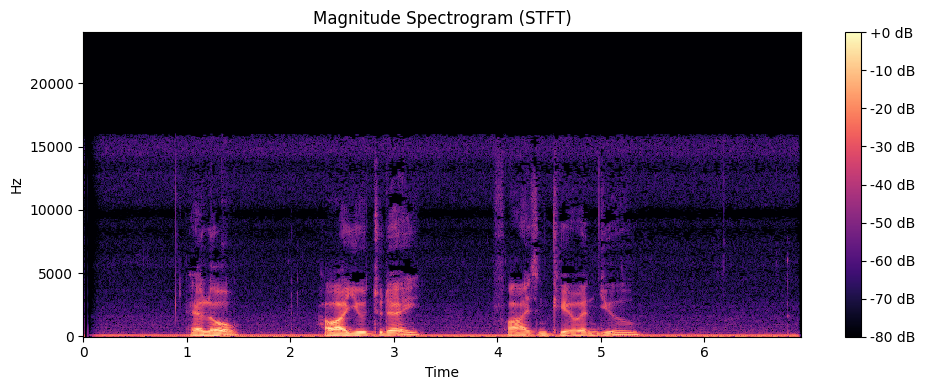

In [6]:
# STFT parameters
n_fft = 1024
hop_length = 256

# Compute STFT and magnitude spectrogram (in dB)
S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
S_mag = np.abs(S)
S_db = librosa.amplitude_to_db(S_mag, ref=np.max)

# Plot spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis="time", y_axis="hz")
plt.colorbar(format="%+2.0f dB")
plt.title("Magnitude Spectrogram (STFT)")
plt.tight_layout()
plt.show()

**Why time–frequency analysis?** Speech is a **non-stationary signal**: its statistics (mean, spectrum) change over time. A single FFT assumes stationarity and loses time information. The **STFT** divides the signal into short overlapping frames, computes the FFT in each frame, and stacks them to form a **spectrogram**. This shows which frequencies are present at each time, revealing formants, pitch, and temporal evolution of phonemes—essential for speech analysis and recognition.

---
## 5. Band-pass FIR Filter

Design a **band-pass FIR filter** for speech with passband **300 Hz – 3400 Hz** (typical telephone/telephony band). We use **scipy.signal.firwin**, apply the filter to the signal, and plot the filtered waveform.

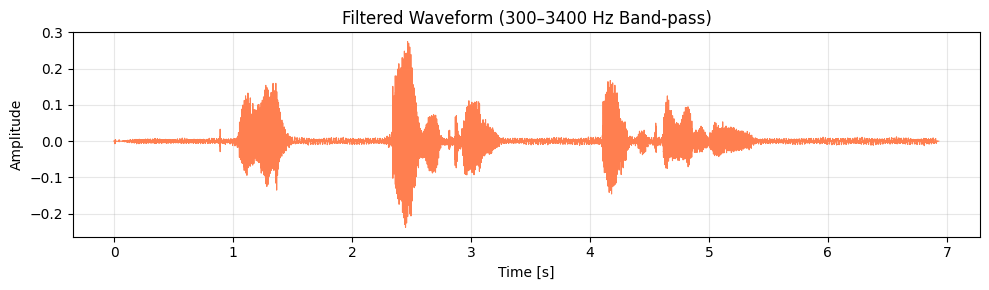

In [7]:
# Filter specifications: 300 Hz - 3400 Hz (speech band)
lowcut = 300   # Hz
highcut = 3400 # Hz
numtaps = 101  # odd for Type I linear-phase FIR
nyq = sr / 2.0
low_norm = lowcut / nyq
high_norm = highcut / nyq

# Design FIR bandpass using firwin (pass_zero=False for bandpass)
fir_coeffs = signal.firwin(numtaps, [low_norm, high_norm], pass_zero=False, window="hamming")

# Apply filter to signal
y_filtered = signal.lfilter(fir_coeffs, 1.0, y)

# Plot filtered waveform
t_f = np.arange(len(y_filtered)) / sr
plt.figure(figsize=(10, 3))
plt.plot(t_f, y_filtered, color="coral", linewidth=0.8)
plt.title("Filtered Waveform (300–3400 Hz Band-pass)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Why 300–3400 Hz?** This band is the standard **telephone/telephony band**. It contains most of the energy needed for intelligibility: fundamental frequency (F0) and lower formants for vowels, and much of the consonant information. Frequencies below ~300 Hz add little to intelligibility but can carry rumble and hum; above ~3.4 kHz the gain in intelligibility diminishes while noise and channel variability often increase. Limiting to this band reduces bandwidth and out-of-band noise in many speech systems.

---
## 6. FIR Filter Analysis

Analyze the designed FIR filter: plot **frequency response**, **phase response**, and **impulse response** using **scipy.signal.freqz** and related tools.

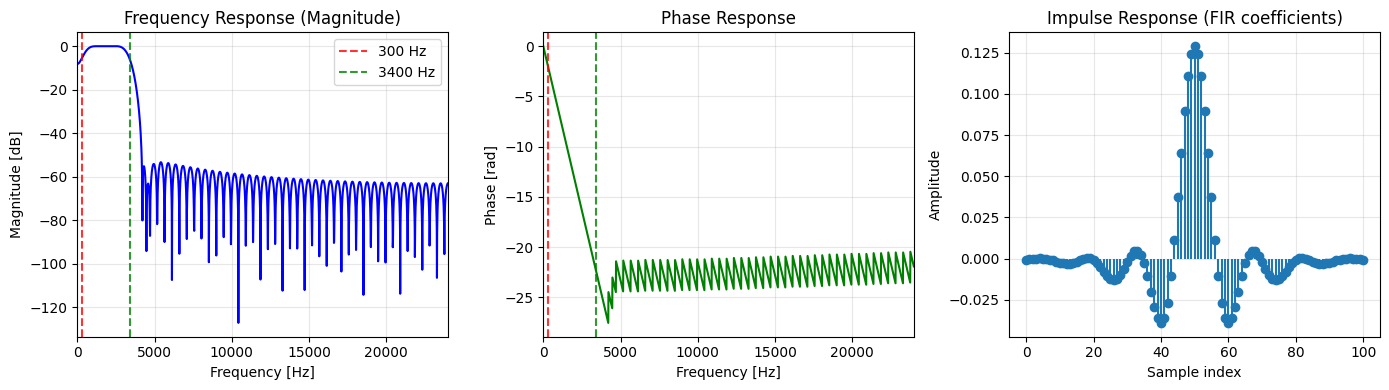

In [8]:
# Frequency and phase response via freqz
w, h = signal.freqz(fir_coeffs, worN=2048)
freqs_hz = w * sr / (2 * np.pi)
mag_db = 20 * np.log10(np.abs(h) + 1e-10)
phase_rad = np.unwrap(np.angle(h))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Frequency response (magnitude)
axes[0].plot(freqs_hz, mag_db, color="blue")
axes[0].axvline(lowcut, color="red", linestyle="--", alpha=0.8, label="300 Hz")
axes[0].axvline(highcut, color="green", linestyle="--", alpha=0.8, label="3400 Hz")
axes[0].set_title("Frequency Response (Magnitude)")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_ylabel("Magnitude [dB]")
axes[0].set_xlim(0, sr / 2)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Phase response
axes[1].plot(freqs_hz, phase_rad, color="green")
axes[1].axvline(lowcut, color="red", linestyle="--", alpha=0.8)
axes[1].axvline(highcut, color="green", linestyle="--", alpha=0.8)
axes[1].set_title("Phase Response")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Phase [rad]")
axes[1].set_xlim(0, sr / 2)
axes[1].grid(True, alpha=0.3)

# Impulse response (filter coefficients = impulse response for FIR)
axes[2].stem(np.arange(numtaps), fir_coeffs, basefmt=" ")
axes[2].set_title("Impulse Response (FIR coefficients)")
axes[2].set_xlabel("Sample index")
axes[2].set_ylabel("Amplitude")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Passband, stopband, phase:** The **passband** is the range of frequencies we want to keep (here 300–3400 Hz); the filter has near-unity gain there. The **stopbands** are the regions we want to attenuate (below 300 Hz and above 3400 Hz). The transition between passband and stopband is gradual (transition band). The **phase response** of this FIR is **linear** in the passband (due to symmetric coefficients), which means no phase distortion—important for preserving timing and shape of speech. The impulse response is finite in length (FIR = Finite Impulse Response).

---
## 7. IIR Filter Comparison

Create an **IIR band-pass filter** using a **Butterworth** design with **scipy.signal.butter**. Plot frequency and phase response, then apply the filter to the signal.

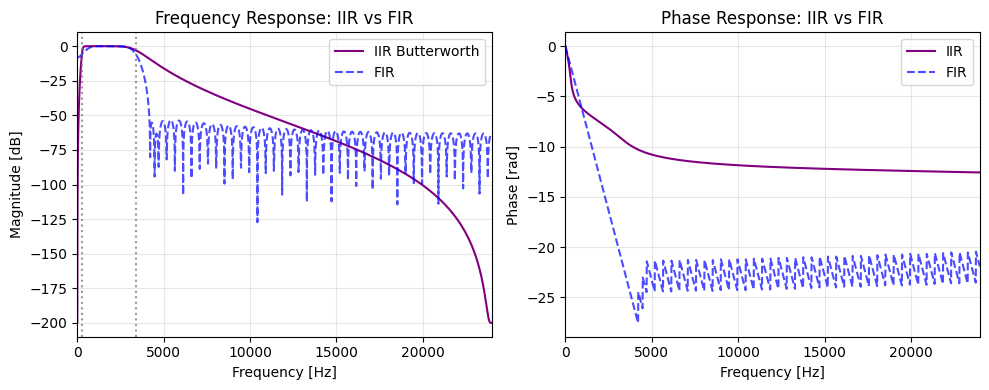

In [9]:
# IIR Butterworth bandpass: same band 300–3400 Hz
order = 4
b_iir, a_iir = signal.butter(order, [low_norm, high_norm], btype="band")

# Frequency and phase response
w_iir, h_iir = signal.freqz(b_iir, a_iir, worN=2048)
freqs_iir = w_iir * sr / (2 * np.pi)
mag_iir_db = 20 * np.log10(np.abs(h_iir) + 1e-10)
phase_iir = np.unwrap(np.angle(h_iir))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(freqs_iir, mag_iir_db, color="purple", label="IIR Butterworth")
axes[0].plot(freqs_hz, mag_db, color="blue", alpha=0.7, linestyle="--", label="FIR")
axes[0].axvline(lowcut, color="gray", linestyle=":", alpha=0.8)
axes[0].axvline(highcut, color="gray", linestyle=":", alpha=0.8)
axes[0].set_title("Frequency Response: IIR vs FIR")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_ylabel("Magnitude [dB]")
axes[0].set_xlim(0, sr / 2)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs_iir, phase_iir, color="purple", label="IIR")
axes[1].plot(freqs_hz, phase_rad, color="blue", alpha=0.7, linestyle="--", label="FIR")
axes[1].set_title("Phase Response: IIR vs FIR")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Phase [rad]")
axes[1].set_xlim(0, sr / 2)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Apply IIR filter to signal (for later comparison if needed)
y_iir = signal.filtfilt(b_iir, a_iir, y)

**FIR vs IIR:** **IIR** filters use feedback (recursive); they can achieve sharp cutoffs with fewer coefficients than FIR but have **non-linear phase** and can be **unstable** if coefficients are not carefully designed. **FIR** filters have no feedback, are always **stable**, and with symmetric coefficients yield **linear phase** (no phase distortion), which is often preferred in speech processing (e.g. for MFCC and timing). IIR is more efficient in terms of order for a given selectivity; FIR is preferred when phase linearity and guaranteed stability matter.

---
## 8. Compare Before vs After Filtering

Show how filtering affects the signal: **waveform comparison**, **FFT comparison**, and **spectrogram comparison**.

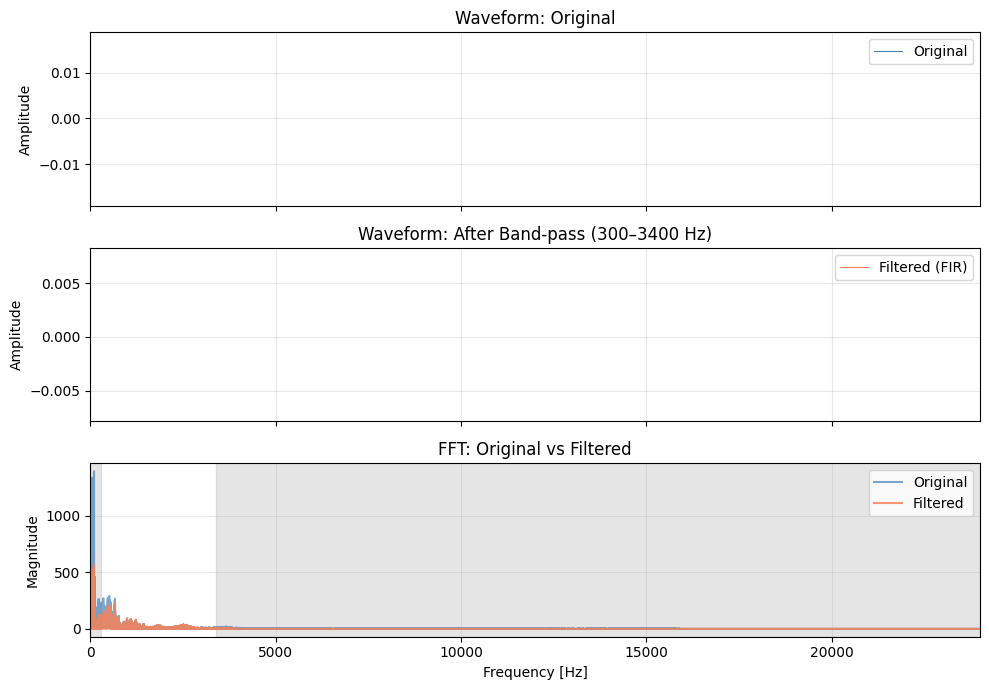

In [10]:
# Waveform comparison (short segment for clarity)
n_show = min( int(0.5 * sr), len(y) )  # first 0.5 s
t_show = np.arange(n_show) / sr

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

axes[0].plot(t_show, y[:n_show], color="steelblue", linewidth=0.8, label="Original")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Waveform: Original")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_show, y_filtered[:n_show], color="coral", linewidth=0.8, label="Filtered (FIR)")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Waveform: After Band-pass (300–3400 Hz)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

# FFT comparison
Y_orig = np.fft.rfft(y)
Y_filt = np.fft.rfft(y_filtered)
freqs_fft = np.fft.rfftfreq(len(y), d=1.0 / sr)
axes[2].plot(freqs_fft, np.abs(Y_orig), color="steelblue", alpha=0.7, label="Original")
axes[2].plot(freqs_fft, np.abs(Y_filt), color="coral", alpha=0.8, label="Filtered")
axes[2].axvspan(0, lowcut, alpha=0.2, color="gray")
axes[2].axvspan(highcut, sr / 2, alpha=0.2, color="gray")
axes[2].set_xlim(0, sr / 2)
axes[2].set_xlabel("Frequency [Hz]")
axes[2].set_ylabel("Magnitude")
axes[2].set_title("FFT: Original vs Filtered")
axes[2].legend(loc="upper right")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

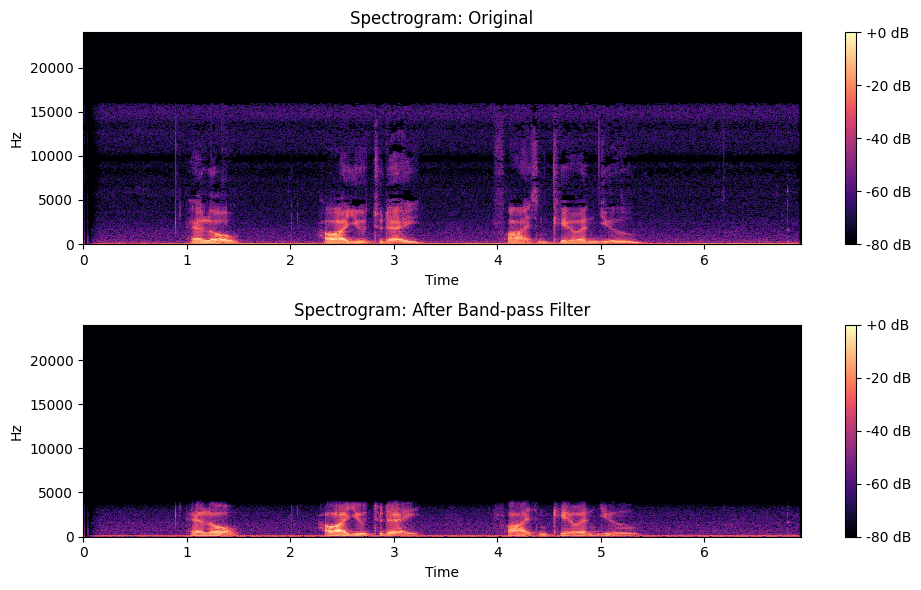

In [11]:
# Spectrogram comparison
S_orig = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))
S_orig_db = librosa.amplitude_to_db(S_orig, ref=np.max)
S_filt = np.abs(librosa.stft(y_filtered, n_fft=n_fft, hop_length=hop_length))
S_filt_db = librosa.amplitude_to_db(S_filt, ref=np.max)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
im0 = librosa.display.specshow(S_orig_db, sr=sr, hop_length=hop_length, x_axis="time", y_axis="hz", ax=axes[0])
axes[0].set_title("Spectrogram: Original")
fig.colorbar(im0, ax=axes[0], format="%+2.0f dB")

im1 = librosa.display.specshow(S_filt_db, sr=sr, hop_length=hop_length, x_axis="time", y_axis="hz", ax=axes[1])
axes[1].set_title("Spectrogram: After Band-pass Filter")
fig.colorbar(im1, ax=axes[1], format="%+2.0f dB")
plt.tight_layout()
plt.show()

**Effect of filtering:** The band-pass filter **removes** energy outside 300–3400 Hz: low-frequency rumble and DC are reduced, and high-frequency hiss/noise is attenuated. The waveform may look slightly different (e.g. less very low-frequency drift). The FFT of the filtered signal shows reduced magnitude outside the passband. The spectrogram of the filtered signal concentrates energy in the speech band and removes out-of-band noise, which can improve feature quality for downstream tasks.

---
## 9. Power Spectral Density (PSD)

Compute **Power Spectral Density** using **Welch's method** (**scipy.signal.welch**) and plot PSD vs frequency.

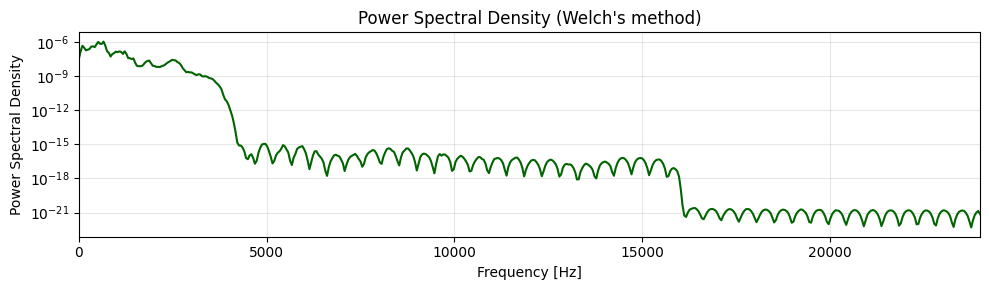

In [12]:
# Welch's method: averaged periodogram for PSD estimate
f_psd, Pxx = signal.welch(y_filtered, sr, nperseg=1024)

plt.figure(figsize=(10, 3))
plt.semilogy(f_psd, Pxx, color="darkgreen")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power Spectral Density")
plt.title("Power Spectral Density (Welch's method)")
plt.xlim(0, sr / 2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**FFT spectrum vs PSD:** A single **FFT magnitude spectrum** is one realization and can be noisy. The **PSD** (Power Spectral Density) estimates *average power per frequency*: Welch's method splits the signal into overlapping segments, computes the squared magnitude of the FFT for each segment, and averages. This reduces variance and gives a smoother, more stable estimate of the power distribution over frequency, which is useful for understanding the signal's spectral content and for noise/voice activity analysis.

---
## 10. Wavelet Transform

Perform the **Continuous Wavelet Transform (CWT)** using **pywt.cwt** and plot the **wavelet scalogram**.

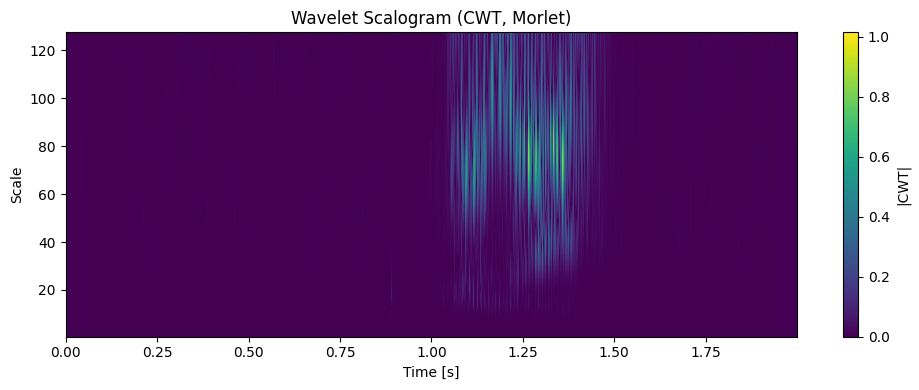

In [13]:
# CWT: use a segment to keep computation manageable
n_cwt = min(len(y_filtered), int(2.0 * sr))  # up to 2 seconds
y_cwt = y_filtered[:n_cwt]
# Scales roughly corresponding to frequencies (pywt uses scale, not direct Hz)
# For Morlet: central_freq ~ 1; scale = central_freq / (f * dt)
dt = 1.0 / sr
scales = np.arange(1, 128)  # scale range for visualization
coef, freqs_cwt = pywt.cwt(y_cwt, scales, "morl", dt)

# Scalogram: magnitude of CWT coefficients
plt.figure(figsize=(10, 4))
t_cwt = np.arange(n_cwt) / sr
plt.pcolormesh(t_cwt, scales, np.abs(coef), shading="auto", cmap="viridis")
plt.colorbar(label="|CWT|")
plt.xlabel("Time [s]")
plt.ylabel("Scale")
plt.title("Wavelet Scalogram (CWT, Morlet)")
plt.tight_layout()
plt.show()

**Wavelet vs STFT:** The **STFT** uses a fixed window size, so time resolution is the same at all frequencies; there is a fixed **time–frequency trade-off**. The **Wavelet Transform** uses short, high-frequency wavelets and long, low-frequency wavelets: **multi-resolution** analysis. So at high frequencies you get better time resolution and at low frequencies better frequency resolution. This can be advantageous for signals like speech where transients (e.g. consonants) need good time resolution and sustained tones (e.g. vowels) need good frequency resolution. Wavelets are also useful for denoising and compression.

---
## 11. Framing

Split the signal into **short frames**. Typical settings: **frame length = 25 ms**, **hop length = 10 ms** (frame shift).

In [14]:
# Frame parameters (typical for speech)
frame_length_ms = 25
hop_length_ms = 10
frame_length = int(sr * frame_length_ms / 1000)   # samples per frame
hop_length = int(sr * hop_length_ms / 1000)       # samples between frame starts

# Number of frames (no padding for simplicity)
n_frames = 1 + (len(y_filtered) - frame_length) // hop_length
print(f"Frame length: {frame_length} samples ({frame_length_ms} ms)")
print(f"Hop length:   {hop_length} samples ({hop_length_ms} ms)")
print(f"Number of frames: {n_frames}")

# Build frame matrix (each column = one frame)
frames = np.array([
    y_filtered[i * hop_length : i * hop_length + frame_length]
    for i in range(n_frames)
    if i * hop_length + frame_length <= len(y_filtered)
])
# If last frame is short, we could pad; here we drop incomplete last frame
if frames.shape[0] != n_frames:
    n_frames = frames.shape[0]
print(f"Frame matrix shape: {frames.shape} (n_frames, frame_length)")

Frame length: 1200 samples (25 ms)
Hop length:   480 samples (10 ms)
Number of frames: 691
Frame matrix shape: (691, 1200) (n_frames, frame_length)


**Why short frames?** Speech is **non-stationary** over long intervals but can be treated as approximately stationary over **short** windows (e.g. 20–30 ms). Within such a window, one phoneme or a stable part of a phoneme dominates, so spectral features (formants, pitch) are meaningful. Short frames also give good **time resolution** for events like plosives and transitions. Typical choices: 25 ms frame length (balance of frequency and time resolution), 10 ms hop (smooth temporal evolution and sufficient overlap).

---
## 12. Windowing

Apply **window functions** to frames: **Hamming** and **Hann** windows. Windowing reduces **spectral leakage** at frame boundaries.

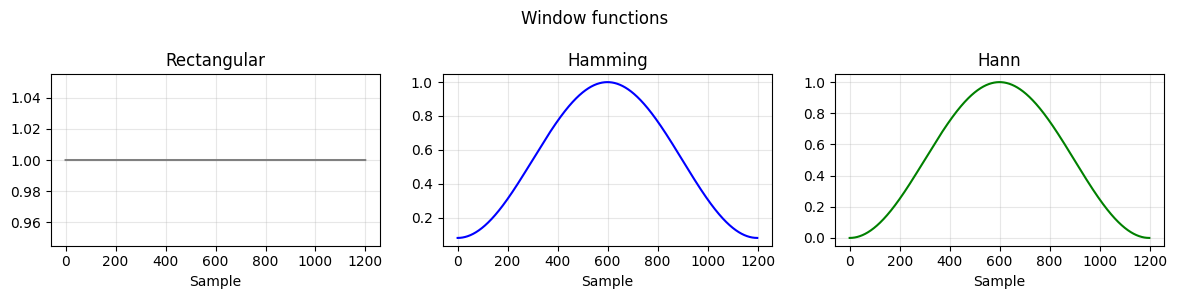

In [15]:
# Window functions (length = frame_length)
win_rect = np.ones(frame_length)                    # rectangular (no window)
win_hamming = np.hamming(frame_length)
win_hann = np.hanning(frame_length)

# Apply Hamming to frames (typical for speech)
frames_hamming = frames * win_hamming
# Or: frames_hamming = frames * win_hamming[np.newaxis, :]

# Visualize windows
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].plot(win_rect, color="gray"); axes[0].set_title("Rectangular"); axes[0].set_xlabel("Sample")
axes[1].plot(win_hamming, color="blue"); axes[1].set_title("Hamming"); axes[1].set_xlabel("Sample")
axes[2].plot(win_hann, color="green"); axes[2].set_title("Hann"); axes[2].set_xlabel("Sample")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.suptitle("Window functions")
plt.tight_layout()
plt.show()

**Spectral leakage and why windowing:** Taking a **rectangular** frame (hard cut at boundaries) is like multiplying the signal by a box; in the frequency domain this convolves the true spectrum with a **sinc** function, causing **spectral leakage**—energy smears to neighboring bins and sidelobes. **Windowing** tapers the frame edges (e.g. Hamming, Hann) so the transition at boundaries is smooth, reducing sidelobes and leakage. Hamming and Hann are commonly used in speech; they trade a slightly wider main lobe for much lower sidelobes than the rectangular window.

---
## 13. Spectral Leakage Experiment

Demonstrate **spectral leakage**: compute FFT with **rectangular**, **Hann**, and **Hamming** windows on a simple sinusoid and plot the results.

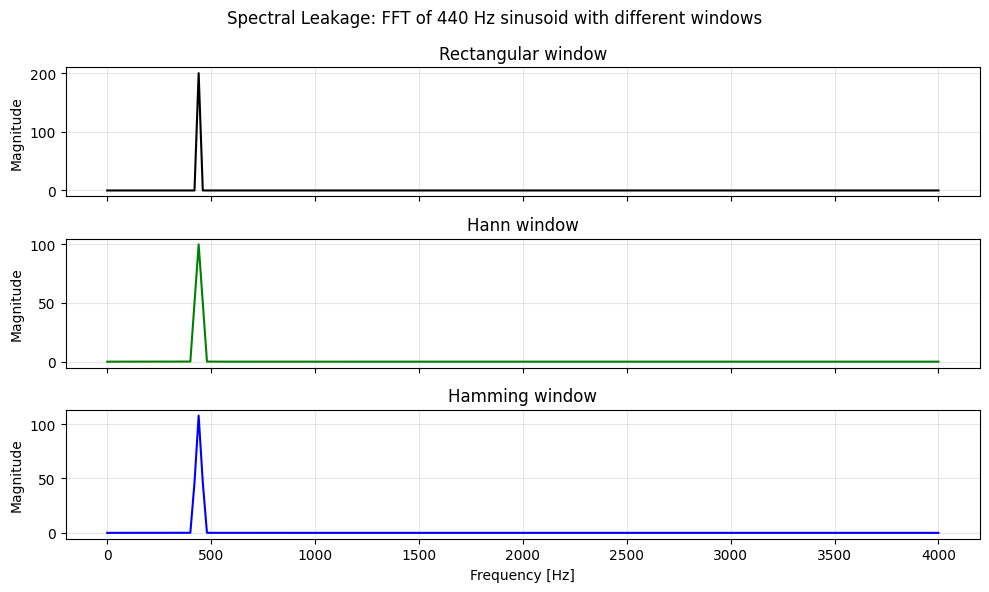

In [16]:
# Test signal: single sinusoid (e.g. 440 Hz) at 8 kHz
fs_test = 8000
duration_test = 0.05  # 50 ms
t_test = np.linspace(0, duration_test, int(fs_test * duration_test), endpoint=False)
f0_test = 440
x_test = np.sin(2 * np.pi * f0_test * t_test)
n_test = len(x_test)

# Apply windows and compute FFT
x_rect = x_test * np.ones(n_test)
x_hann = x_test * np.hanning(n_test)
x_hamm = x_test * np.hamming(n_test)

fft_rect = np.abs(np.fft.rfft(x_rect))
fft_hann = np.abs(np.fft.rfft(x_hann))
fft_hamm = np.abs(np.fft.rfft(x_hamm))
freqs_test = np.fft.rfftfreq(n_test, d=1.0 / fs_test)

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].plot(freqs_test, fft_rect, color="black"); axes[0].set_title("Rectangular window"); axes[0].set_ylabel("Magnitude"); axes[0].grid(True, alpha=0.3)
axes[1].plot(freqs_test, fft_hann, color="green");  axes[1].set_title("Hann window");     axes[1].set_ylabel("Magnitude"); axes[1].grid(True, alpha=0.3)
axes[2].plot(freqs_test, fft_hamm, color="blue");  axes[2].set_title("Hamming window");  axes[2].set_ylabel("Magnitude"); axes[2].set_xlabel("Frequency [Hz]"); axes[2].grid(True, alpha=0.3)
plt.suptitle("Spectral Leakage: FFT of 440 Hz sinusoid with different windows")
plt.tight_layout()
plt.show()

**Interpretation:** With a **rectangular** window, the spectrum shows a sharp peak at 440 Hz but also **sidelobes** (leakage) at other frequencies. **Hann** and **Hamming** windows suppress sidelobes: the main lobe may be slightly wider, but leakage is greatly reduced. This is why we window frames before taking the FFT in speech processing.

---
## 14. Window Size Experiment

Show how **window size** (FFT length) affects the STFT. Use window sizes **256**, **512**, **1024**, **2048** and plot spectrograms.

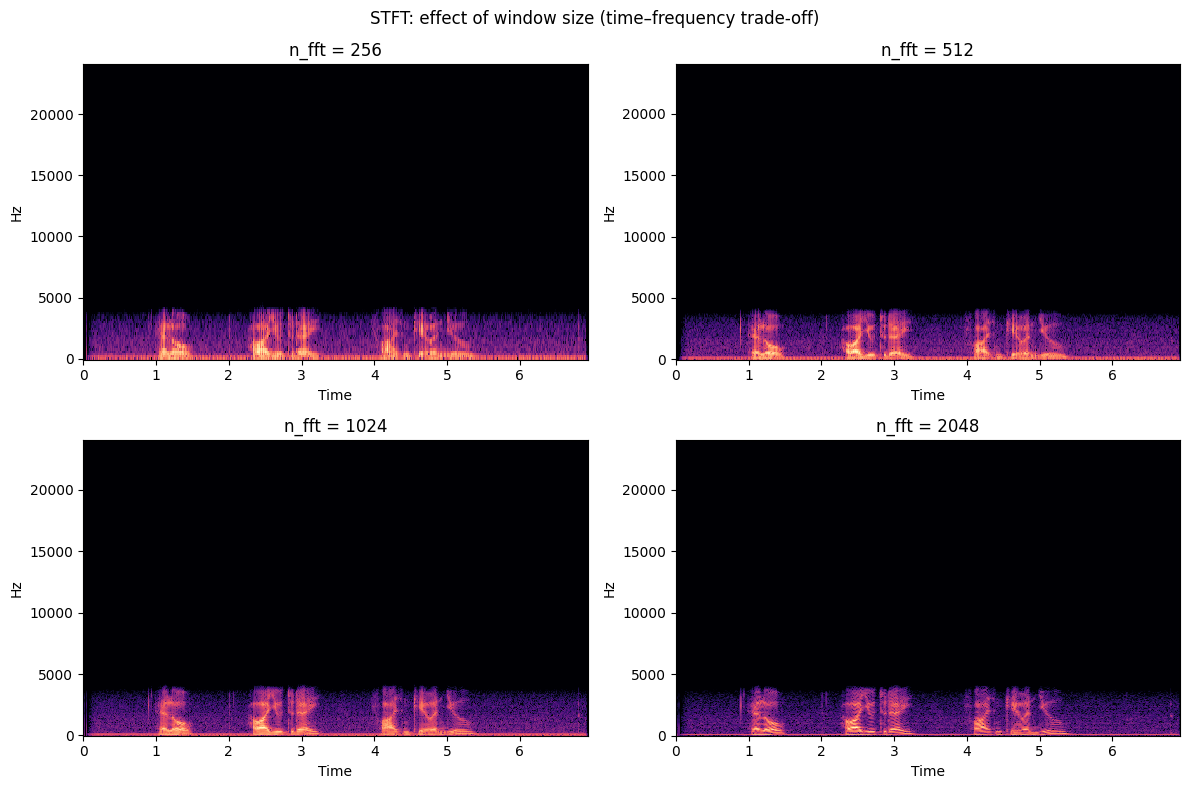

In [17]:
# STFT with different n_fft (window sizes)
sizes = [256, 512, 1024, 2048]
hop = 256
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for idx, n in enumerate(sizes):
    S = np.abs(librosa.stft(y_filtered, n_fft=n, hop_length=hop))
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, hop_length=hop, x_axis="time", y_axis="hz", ax=axes[idx])
    axes[idx].set_title(f"n_fft = {n}")
plt.suptitle("STFT: effect of window size (time–frequency trade-off)")
plt.tight_layout()
plt.show()

**Time–frequency trade-off:** Larger **n_fft** (longer window) gives **better frequency resolution** (narrower bins) but **worse time resolution** (longer window smears events in time). Smaller n_fft gives better time resolution but coarser frequency resolution. For speech, 512–1024 is often a good compromise. The four plots show this: larger n_fft yields sharper horizontal (frequency) structure; smaller n_fft yields sharper vertical (time) structure.

---
## 15. Feature Extraction

Extract speech features from the **filtered** signal:

- **MFCC** (13 coefficients)
- **Spectral Centroid**
- **Zero Crossing Rate**
- **Band Energy** (300–3400 Hz)

Visualize: MFCC heatmap and feature plots over time.

In [18]:
# Feature extraction on filtered signal (using librosa with consistent framing)
n_fft_feat = 1024
hop_feat = 256
n_mfcc = 13

# MFCC (13 coefficients)
mfcc = librosa.feature.mfcc(y=y_filtered, sr=sr, n_fft=n_fft_feat, hop_length=hop_feat, n_mfcc=n_mfcc)

# Spectral centroid
centroid = librosa.feature.spectral_centroid(y=y_filtered, sr=sr, n_fft=n_fft_feat, hop_length=hop_feat)

# Zero crossing rate
zcr = librosa.feature.zero_crossing_rate(y_filtered, frame_length=n_fft_feat, hop_length=hop_feat)

# Band energy 300–3400 Hz: use mel or linear filter; here we use power in that band via STFT
S = np.abs(librosa.stft(y_filtered, n_fft=n_fft_feat, hop_length=hop_feat)) ** 2
freqs_stft = librosa.fft_frequencies(sr=sr, n_fft=n_fft_feat)
mask = (freqs_stft >= 300) & (freqs_stft <= 3400)
band_energy = np.sum(S[mask, :], axis=0)
band_energy = np.log1p(band_energy)  # log scale for visualization

# Time axis for features (same number of frames)
n_frames_feat = mfcc.shape[1]
times_feat = librosa.frames_to_time(np.arange(n_frames_feat), sr=sr, hop_length=hop_feat)

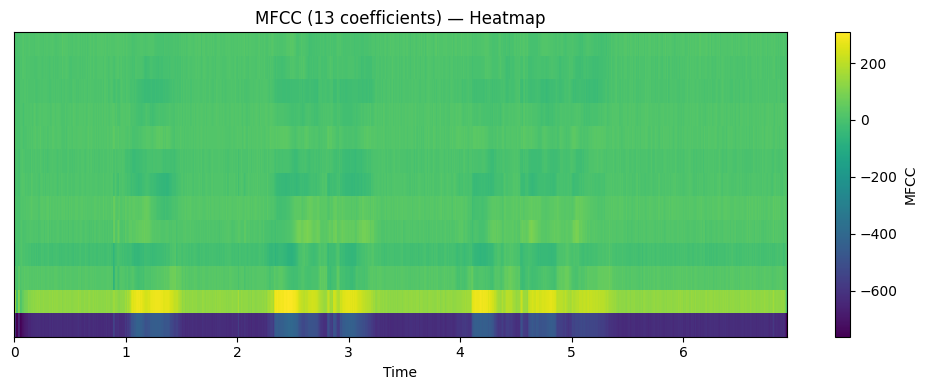

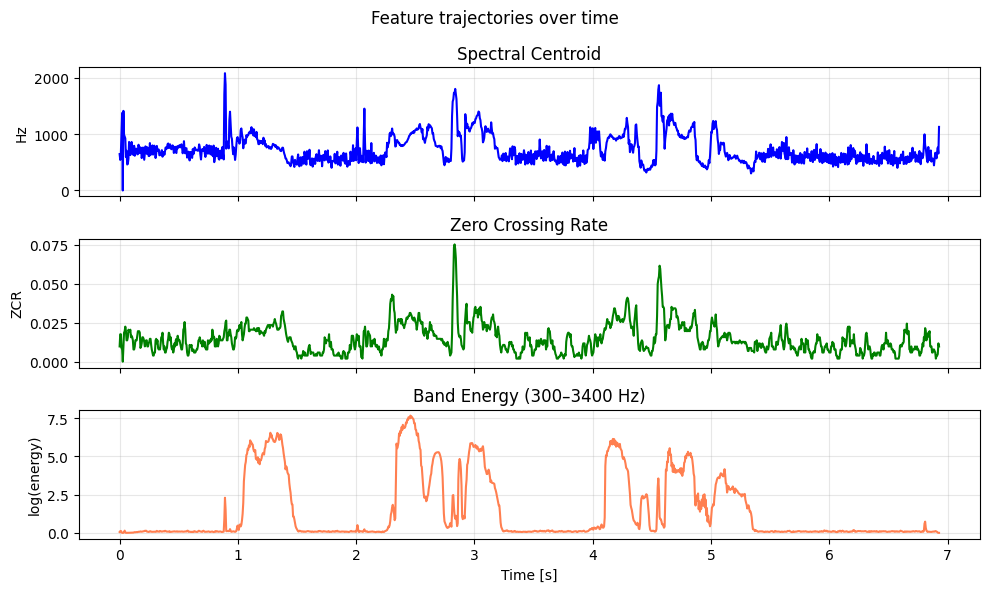

In [19]:
# MFCC heatmap
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, sr=sr, hop_length=hop_feat, x_axis="time", cmap="viridis")
plt.colorbar(label="MFCC")
plt.title("MFCC (13 coefficients) — Heatmap")
plt.tight_layout()
plt.show()

# Feature plots over time
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].plot(times_feat, centroid.flatten(), color="blue"); axes[0].set_ylabel("Hz"); axes[0].set_title("Spectral Centroid"); axes[0].grid(True, alpha=0.3)
axes[1].plot(times_feat, zcr.flatten(), color="green");  axes[1].set_ylabel("ZCR"); axes[1].set_title("Zero Crossing Rate"); axes[1].grid(True, alpha=0.3)
axes[2].plot(times_feat, band_energy, color="coral");     axes[2].set_ylabel("log(energy)"); axes[2].set_title("Band Energy (300–3400 Hz)"); axes[2].set_xlabel("Time [s]"); axes[2].grid(True, alpha=0.3)
plt.suptitle("Feature trajectories over time")
plt.tight_layout()
plt.show()

**What each feature represents:**

- **MFCC (Mel-frequency cepstral coefficients):** Encode the **spectral envelope** in a compact way. The mel scale approximates human hearing; the DCT decorrelates coefficients. MFCCs are standard in speaker and speech recognition.
- **Spectral centroid:** The "center of mass" of the spectrum in Hz; related to **brightness** (high centroid = brighter sound).
- **Zero crossing rate (ZCR):** Rate of sign changes per frame; higher for **noisy/unvoiced** segments (e.g. fricatives), lower for voiced vowels.
- **Band energy (300–3400 Hz):** Total energy in the speech band; reflects **loudness/activity** in the frequency range most relevant for speech.

---
## 16. Feature Interpretation

How the extracted features relate to speech properties:

- **MFCC:** Represent the **spectral envelope** (shape of the spectrum), which is influenced by the vocal tract. Different phonemes and speakers produce different envelope shapes, so MFCCs are core for speaker identification and speech classification.
- **Spectral centroid:** Indicates **brightness**: high values for fricatives and high vowels, lower for back vowels and voiced sonorants.
- **Zero crossing rate:** Reflects **noisiness** and voicing: unvoiced consonants (e.g. /s/, /f/) have high ZCR; voiced vowels have lower ZCR. Useful for voice activity and phoneme class discrimination.
- **Band energy (300–3400 Hz):** Captures **speech energy** in the telephony band. Tracks overall loudness and can help segment speech from silence or non-speech.

---
## 17. DSP Pipeline Summary

A concise summary of the full pipeline and its role in preparing speech for machine learning.

**Pipeline stages:**

1. **Raw speech signal** — Load .wav, inspect duration and sample rate; waveform gives time-domain view.
2. **Filtering** — Band-pass (300–3400 Hz) removes out-of-band noise and focuses on the speech band; FIR preferred for linear phase.
3. **Frequency analysis** — FFT gives global spectrum; PSD (Welch) gives a stable power estimate; STFT gives time–frequency representation (spectrogram).
4. **Time–frequency analysis** — Spectrogram (STFT) and wavelet (CWT) reveal how frequency content changes over time, essential for non-stationary speech.
5. **Framing and windowing** — Split into short frames (e.g. 25 ms), apply a window (e.g. Hamming) to reduce spectral leakage.
6. **Feature extraction** — Compute MFCCs, spectral centroid, ZCR, band energy (and others) per frame to obtain compact, informative descriptors.

**Role in ML:** This pipeline turns a raw waveform into **frame-level feature vectors** (e.g. 13-D MFCCs plus other stats) that can be fed to classifiers or sequence models. Such features are standard for **speaker identification**, **speech recognition**, and **speech classification**, where the goal is to learn from spectral and temporal patterns rather than raw samples.